In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid", palette="muted")

print("Import libraries สำเร็จ")

Import libraries สำเร็จ


In [4]:
# โหลดข้อมูล
df = pd.read_csv('../data/social_media_data.csv')

# ตรวจสอบเบื้องต้น
print("=" * 45)
print(f"จำนวนแถว : {df.shape[0]}")
print(f"จำนวนคอลัมน์ : {df.shape[1]}")
print("=" * 45)
print("\nชื่อคอลัมน์:")
print(df.columns.tolist())
print("\nตัวอย่างข้อมูล 5 แถวแรก:")
print(df.head())
print("\nตรวจสอบค่าว่าง:")
print(df.isnull().sum())
print("\nสถิติเบื้องต้น:")
print(df.describe().round(2))

จำนวนแถว : 1000
จำนวนคอลัมน์ : 11

ชื่อคอลัมน์:
['platform', 'content_type', 'day_of_week', 'hour', 'followers', 'hashtags', 'likes', 'comments', 'shares', 'reach', 'engagement_rate']

ตัวอย่างข้อมูล 5 แถวแรก:
    platform content_type day_of_week  hour  followers  hashtags  likes  \
0     TikTok         Text   Wednesday    19       1343         3     25   
1  Instagram     Carousel    Saturday     8       4043         9     34   
2  Instagram        Video      Sunday    13       3151        15     41   
3  Instagram         Text    Thursday    15       6566         7     39   
4  Instagram        Image     Tuesday    17      11084        16     49   

   comments  shares  reach  engagement_rate  
0         1       0    571           0.0298  
1         2       1   1641           0.0130  
2         1       2    583           0.0195  
3         3       2   3391           0.0106  
4         5       3   6315           0.0081  

ตรวจสอบค่าว่าง:
platform           0
content_type       0
day_

In [5]:
# สร้าง SQLite database จาก dataframe
conn = sqlite3.connect('../data/social_media.db')
df.to_sql('posts', conn, if_exists='replace', index=False)
print("สร้าง database สำเร็จ")

# Query 1: engagement rate เฉลี่ยแต่ละ platform
q1 = pd.read_sql_query("""
    SELECT platform,
           COUNT(*) as total_posts,
           ROUND(AVG(engagement_rate) * 100, 2) as avg_engagement_pct,
           ROUND(AVG(likes), 0) as avg_likes,
           ROUND(AVG(comments), 0) as avg_comments
    FROM posts
    GROUP BY platform
    ORDER BY avg_engagement_pct DESC
""", conn)
print("\nQuery 1: Engagement Rate แต่ละ Platform")
print(q1.to_string(index=False))

# Query 2: content type ไหน engagement ดีที่สุด
q2 = pd.read_sql_query("""
    SELECT content_type,
           COUNT(*) as total_posts,
           ROUND(AVG(engagement_rate) * 100, 2) as avg_engagement_pct,
           ROUND(AVG(likes), 0) as avg_likes
    FROM posts
    GROUP BY content_type
    ORDER BY avg_engagement_pct DESC
""", conn)
print("\nQuery 2: Engagement Rate แต่ละ Content Type")
print(q2.to_string(index=False))

# Query 3: วันไหน engagement ดีที่สุด
q3 = pd.read_sql_query("""
    SELECT day_of_week,
           ROUND(AVG(engagement_rate) * 100, 2) as avg_engagement_pct,
           ROUND(AVG(likes), 0) as avg_likes
    FROM posts
    GROUP BY day_of_week
    ORDER BY avg_engagement_pct DESC
""", conn)
print("\nQuery 3: Engagement Rate แต่ละวัน")
print(q3.to_string(index=False))

# Query 4: hashtag กี่อันดีที่สุด
q4 = pd.read_sql_query("""
    SELECT
        CASE
            WHEN hashtags = 0 THEN '0 (ไม่ใช้)'
            WHEN hashtags BETWEEN 1 AND 5 THEN '1-5'
            WHEN hashtags BETWEEN 6 AND 15 THEN '6-15 (แนะนำ)'
            WHEN hashtags BETWEEN 16 AND 25 THEN '16-25'
            ELSE '26+ (มากเกินไป)'
        END as hashtag_group,
        COUNT(*) as total_posts,
        ROUND(AVG(engagement_rate) * 100, 2) as avg_engagement_pct
    FROM posts
    GROUP BY hashtag_group
    ORDER BY avg_engagement_pct DESC
""", conn)
print("\nQuery 4: Hashtag กับ Engagement")
print(q4.to_string(index=False))

print("\nSQL queries ทั้งหมดสำเร็จ")

สร้าง database สำเร็จ

Query 1: Engagement Rate แต่ละ Platform
 platform  total_posts  avg_engagement_pct  avg_likes  avg_comments
 LinkedIn          190                8.11     1393.0         112.0
   TikTok          248                2.57      351.0          26.0
Instagram          322                1.50      277.0          18.0
 Facebook          147                0.68      110.0           7.0
  Twitter           93                0.16       36.0           2.0

Query 2: Engagement Rate แต่ละ Content Type
content_type  total_posts  avg_engagement_pct  avg_likes
       Video          362                3.41      534.0
    Carousel          185                2.82      335.0
       Image          299                2.46      476.0
        Text          154                1.85      407.0

Query 3: Engagement Rate แต่ละวัน
day_of_week  avg_engagement_pct  avg_likes
    Tuesday                3.53      546.0
     Monday                2.91      341.0
   Saturday                2.83    

In [7]:
import os

# สร้าง folder images ถ้ายังไม่มี
os.makedirs('../images', exist_ok=True)
print("พร้อมบันทึกรูปแล้ว")

พร้อมบันทึกรูปแล้ว


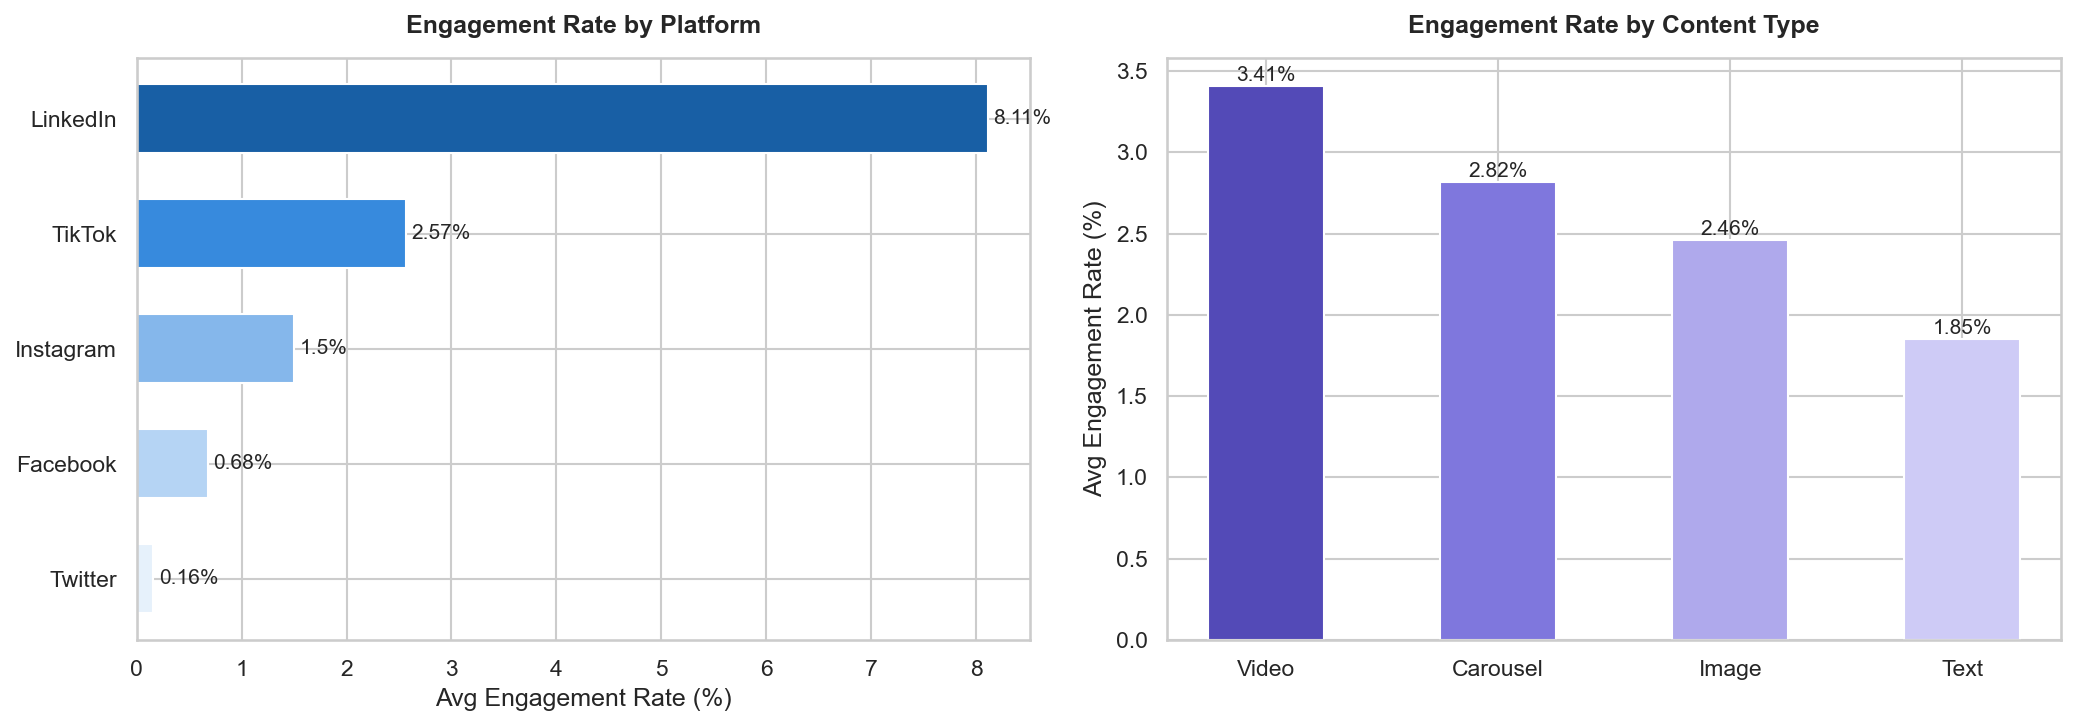

บันทึกกราฟ 1-2 สำเร็จ


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟ 1: Engagement Rate แต่ละ Platform
colors1 = ['#185FA5','#378ADD','#85B7EB','#B5D4F4','#E6F1FB']
bars1 = axes[0].barh(q1['platform'], q1['avg_engagement_pct'],
                     color=colors1, edgecolor='white', height=0.6)
axes[0].set_xlabel('Avg Engagement Rate (%)')
axes[0].set_title('Engagement Rate by Platform', fontweight='bold', pad=12)
axes[0].invert_yaxis()
for bar, val in zip(bars1, q1['avg_engagement_pct']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=10)

# กราฟ 2: Engagement Rate แต่ละ Content Type
colors2 = ['#534AB7','#7F77DD','#AFA9EC','#CECBF6']
bars2 = axes[1].bar(q2['content_type'], q2['avg_engagement_pct'],
                    color=colors2, edgecolor='white', width=0.5)
axes[1].set_ylabel('Avg Engagement Rate (%)')
axes[1].set_title('Engagement Rate by Content Type', fontweight='bold', pad=12)
for bar, val in zip(bars2, q2['avg_engagement_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                 f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/chart1_platform_content.png', dpi=150, bbox_inches='tight')
plt.show()
print("บันทึกกราฟ 1-2 สำเร็จ")